In [1]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve
import nifty8.re as jft

from copy import deepcopy
from jax.lax import slice as jax_slice

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type, domain_tree, model_init, correlated_field_model, optimize_kl

jax.config.update("jax_enable_x64", True)

key = jax.random.PRNGKey(123)

Could not import MPI
/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class SignalGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, space, center=(0,0), factor=1, distances=(1.,1.)):
        check_type(space, tuple, int)
        check_type(factor, int)
        check_type(center, tuple, int)
        check_type(distances, tuple, float)

        self.space = space
        self.center = center
        self.factor = factor
        self.shape = tuple(d*self.factor for d in self.space)
        self.distances = distances

    def __repr__(self):
        return f'SignalGrid(space={self.space}, center={self.center}, factor={self.factor}, distances={self.distances})'
    
    def __mul__(self, other):
        return self.multiply_space(other)
    
    def __rmul__(self, other):
        return self.__mul__(other)

    @property
    def dom(self):
        return np.array(self.space)

    @property
    def cen(self):
        return np.array(self.center)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()
    
    @property
    def dis(self):
        return np.array(self.distances) / self.factor
    
    @property
    def coos(self):
        coos = np.indices(self.shp).astype(float)
        coos_T = coos.T.reshape(-1, 2)
        coos_T -= 0.5 * (self.shp - 1)
        coos_T /= self.factor
        coos_T += self.cen
        return coos_T.reshape(coos.T.shape).T

    @property
    def llp(self):
        return self.cen - 0.5 * (self.shp - 1) / self.factor

    @property
    def urp(self):
        return self.cen + 0.5 * (self.shp - 1) / self.factor

    def update(self, space=None, center=None, factor=None, distances=None):
        space = self.space if space is None else space
        center = self.center if center is None else center
        factor = self.factor if factor is None else factor
        distances = self.distances if distances is None else distances
        return SignalGrid(space, center, factor, distances)
    
    def multiply_space(self, factor):
        return SignalGrid.update(self, space=tuple(int(si * factor) for si in self.space))



def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def map_array(in_array, in_grid, out_grid):
    factor = 1
    if out_grid.factor < in_grid.factor:
        in_array = downsample(in_array, in_grid.factor // out_grid.factor)
        in_grid = in_grid.update(factor=out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    if in_grid.center != out_grid.center or in_grid.space != out_grid.space:
        out_array = jnp.zeros(out_grid.shape)

        llp_dif = (out_grid.llp - in_grid.llp).astype('int64')
        urp_dif = (out_grid.urp - in_grid.urp).astype('int64')

        in_min = np.maximum(llp_dif * in_grid.factor, 0)
        in_max = np.minimum(urp_dif * in_grid.factor + in_grid.shp, in_grid.shp)
        in_slc = tuple(slice(in_min[i], in_max[i]) for i in range(2))

        out_min = np.maximum(- llp_dif * out_grid.factor, 0)
        out_max = np.minimum(out_grid.shp - urp_dif * out_grid.factor, out_grid.shp)
        out_slc = tuple(slice(out_min[i], out_max[i]) for i in range(2))
        
        out_array = out_array.at[out_slc].set(in_array[in_slc])
    else:
        out_array = in_array.copy()

    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array

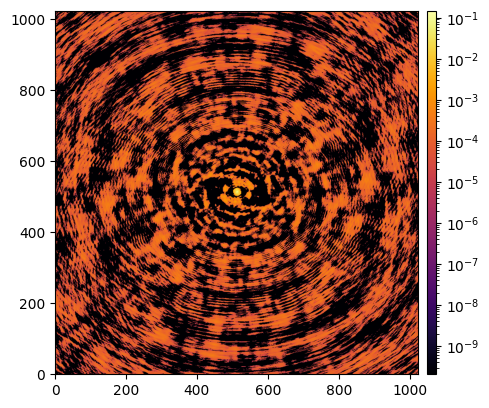

In [144]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val



obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()

space = SignalSpace.build(shape=(512,512), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space)
kernel = compute_psf_kernel(RNR_l)

plot_arrays(kernel, norm='log', dpi=100)

In [145]:
class SignalModel(jft.Model):

    def __init__(self, grid, i0, prefix='sm'):
        self.grid = grid
        self.i0 = i0
        self.prefix = prefix
        super().__init__(domain=self.i0.domain, init=self.i0.init)

    def __call__(self, x, *, out_grid=None):
        res = jnp.exp(self.i0(x))
        if out_grid:
            return map_array(res, self.grid, out_grid)
        return res

In [209]:
def jax_fft(grid):
    check_type(grid, SignalGrid)
    dvol = grid.dis.prod()
    return lambda x: dvol * jnp.fft.fftn(x)


def jax_ifft(grid):
    check_type(grid, SignalGrid)
    dvol = 1. / (grid.shp * grid.dis).prod()
    npix = grid.size
    return lambda x: dvol * npix * jnp.fft.ifftn(x)


def jax_fft_convolve(fft_kernel, grid):
    grid_l = grid.update(space=tuple(s*2 for s in grid.space))
    fft_l = jax_fft(grid_l)
    ifft_l = jax_ifft(grid_l)
    padding = grid.shp // 2

    def jax_fft_conv(array):
        p_array = jnp.pad(array, (2*(padding[0],), 2*(padding[1],)))
        c_array = ifft_l(fft_kernel * fft_l(p_array)).real
        s_array = jax_slice(c_array, padding, padding + grid.shp)
        return s_array

    return jax_fft_conv


def shift_kernel(kernel):
    s_kernel = jnp.roll(kernel, -kernel.shape[0]//2, axis=0)
    s_kernel = jnp.roll(s_kernel, -kernel.shape[1]//2, axis=1)
    return s_kernel


def build_fft_kernel(kernel, grid):
    check_type(grid, SignalGrid)
    grid_l = grid.update(space=tuple(s*2 for s in grid.space))
    s_kernel = shift_kernel(kernel)
    f_kernel = jax_fft(grid_l)(s_kernel)
    return f_kernel


def build_lowres_kernel(kernel, grid):
    l_kernel = downsample(kernel, grid.factor)
    l_grid = grid.update(factor=1)
    return build_fft_kernel(l_kernel, l_grid)


def build_center_kernel(kernel, grid):
    c_shape = tuple(s//grid.factor for s in kernel.shape)
    c_slice = tuple(slice(k//2 - c//2, k//2 + c//2) for k,c in zip(kernel.shape, c_shape))
    c_kernel = kernel[c_slice]
    return build_fft_kernel(c_kernel, grid.update(factor=1))


def build_multires_kernel(kernel, grid):
    l_kernel = build_lowres_kernel(kernel, grid)
    c_kernel = build_center_kernel(kernel, grid)
    f_kernel = np.stack([l_kernel, c_kernel])
    return f_kernel


def build_facet_grids(grid):
    f_space = tuple(s // grid.factor for s in grid.space)
    f_coos = np.linspace(-1 + 1/grid.factor, 1 - 1/grid.factor, grid.factor)
    f_center = np.array(np.meshgrid(f_coos, f_coos)).T.reshape(-1, 2) * np.array(grid.space) // 2
    
    f_grids = []
    for fc in f_center:
        f_cen = tuple(int(c) for c in fc)
        f_grid = grid.update(space=f_space, center=f_cen)
        f_grids.append(f_grid)

    return f_grids


def build_facet_array(array, factor):
    f_shape = tuple(s//factor for s in array.shape)
    f_array = array.reshape(factor, f_shape[0], factor, f_shape[1])
    f_array = f_array.transpose(0,2,1,3)
    f_array = f_array.reshape(-1, f_shape[0], f_shape[1])
    return f_array


def merge_facet_array(f_array, factor):
    f_shape = f_array.shape[1:]
    array = f_array.reshape(factor, factor, f_shape[0], f_shape[1])
    array = array.transpose(0, 2, 1, 3)
    array = array.reshape(factor*f_shape[0], factor*f_shape[1])
    return array



def reorder_facet_array(array):
    factor = int(np.sqrt(array.shape[0]))
    grid = np.arange(factor**2).reshape((factor, factor))
    order = grid.T[::-1].flatten()
    return array[order]



class LowResResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.grid = model.grid

        self.grid_low = self.grid.update(factor=1)
        self.fft_kernel_low = build_lowres_kernel(kernel, self.grid)
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        sig_low = self.model(x, out_grid=self.grid_low)
        rsp_low = jax_fft_convolve(jnp.array(self.fft_kernel_low), self.grid_low)(sig_low)
        return rsp_low



class HighResResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.grid = model.grid
        self.fft_kernel = build_fft_kernel(kernel, self.grid)
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        sig = self.model(x)
        rsp = jax_fft_convolve(jnp.array(self.fft_kernel), self.grid)(sig)
        return rsp
    


class FacetResponse(jft.Model):

    def __init__(self, model, kernel):
        self.model = model
        self.grid = model.grid
        self.factor = model.grid.factor

        self.l_grid = self.grid.update(factor=1)

        self.f_grids = [
            self.grid.update(space=tuple(s//self.factor for s in self.grid.space), center=(0,-5)),
            self.grid.update(space=tuple(s//self.factor for s in self.grid.space), center=(-10,20)),
        ]
        self.f_masks = [map_array(np.ones(f_grid.shape), f_grid, self.l_grid) for f_grid in self.f_grids]
        self.fft_kernel = build_multires_kernel(kernel, self.grid)
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        l_sig = self.model(x, out_grid=self.l_grid)

        f_responses = jnp.zeros((len(self.f_grids),) + self.l_grid.shape)
        for i in range(len(self.f_grids)):
            m_sig = (1 - self.f_masks[i]) * l_sig
            m_rsp = jax_fft_convolve(jnp.array(self.fft_kernel[0]), self.l_grid)(m_sig)
            m_rsp = map_array(m_rsp, self.l_grid, self.f_grids[i])

            f_sig = self.model(x, out_grid=self.f_grids[i])

            f_rsp = jax_fft_convolve(jnp.array(self.fft_kernel[1]), self.f_grids[i])(f_sig)

            f_rsp = m_rsp + f_rsp / (self.factor**2)
            f_responses = f_responses.at[i].set(f_rsp)

        return f_responses



class MultiResResponse(jft.Model):

    def __init__(self, model, kernel):
        self.model = model
        self.grid = model.grid
        self.factor = model.grid.factor

        self.l_grid = self.grid.update(factor=1)

        self.f_grids = [
            self.grid.update(space=tuple(s//self.factor for s in self.grid.space), center=(0,-5)),
            self.grid.update(space=tuple(s//self.factor for s in self.grid.space), center=(-10,20)),
        ]
        self.f_masks = [map_array(np.ones(f_grid.shape), f_grid, self.l_grid) for f_grid in self.f_grids]
        self.fft_kernel = build_multires_kernel(kernel, self.grid)
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        l_sig = self.model(x, out_grid=self.l_grid)
        l_rsp = jax_fft_convolve(jnp.array(self.fft_kernel[0]), self.l_grid)(l_sig)

        m_sig = (1 - self.f_mask) * l_sig
        m_rsp = jax_fft_convolve(jnp.array(self.fft_kernel[0]), self.l_grid)(m_sig)
        m_rsp = map_array(m_rsp, self.l_grid, self.f_grid)

        f_sig = self.model(x, out_grid=self.f_grid)
        f_rsp = jax_fft_convolve(jnp.array(self.fft_kernel[1]), self.f_grid)(f_sig)

        rsp = jnp.stack([l_rsp, m_rsp + f_rsp / (self.factor**2)])
        return rsp

SignalGrid(space=(128, 128), center=(0, 0), factor=4, distances=(0.000272707695624114, 0.000272707695624114))


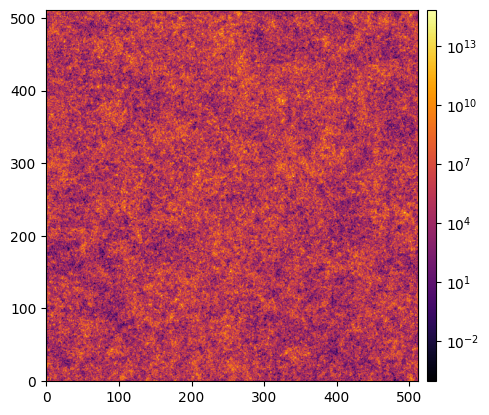

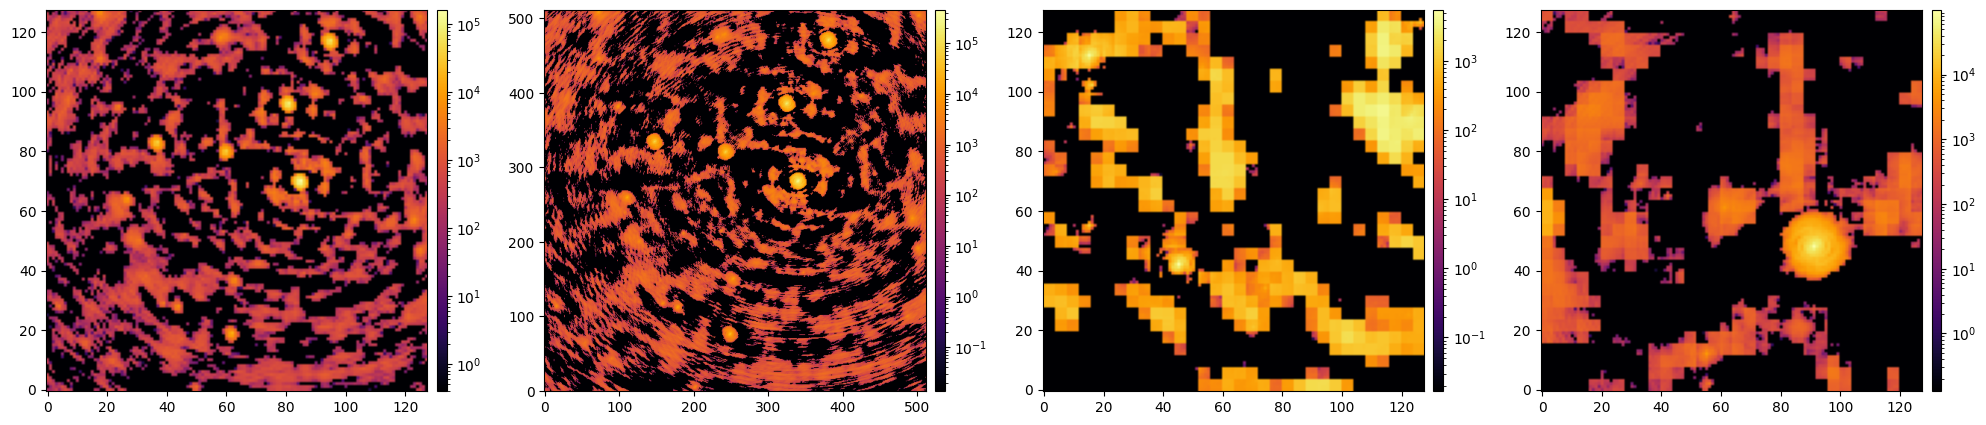

In [210]:
shape = (128, 128)
factor = 4

space = SignalSpace.build(shape=shape, fov=('2deg', '2deg'))

grid = SignalGrid(space=shape, center=(0,0), factor=factor, distances=space.distances)
print(grid)

bg, pw = correlated_field_model(
    prefix='bg ',
    shape=grid.shape,
    distances=grid.distances,
    offset_mean=12,
    offset_std=(1,0.1),
    fluctuations=(5,1),
    loglogavgslope=(-2,0.5),
)
signal = SignalModel(grid, bg, prefix='bg')


lr_response = LowResResponse(signal, kernel)

hr_response = HighResResponse(signal, kernel)

# mr_response = MultiResResponse(signal, kernel)

fr_response = FacetResponse(signal, kernel)


key, subkey = jax.random.split(key)
prior_xi = signal.init(subkey)

# plot_arrays([sig_bg(prior_xi), sig_t0(prior_xi), sig_t1(prior_xi), signal(prior_xi)], rows=1, norm='log')
plot_arrays(signal(prior_xi), rows=1, norm='log')

# plot_arrays([lr_response(prior_xi), hr_response(prior_xi), map_array(hr_response(prior_xi), grid, fr_response.f_grid), mr_response(prior_xi)[0], mr_response(prior_xi)[1]], rows=1, norm='log')
plot_arrays([lr_response(prior_xi), hr_response(prior_xi), fr_response(prior_xi)[0], fr_response(prior_xi)[1]], rows=1, norm='log')


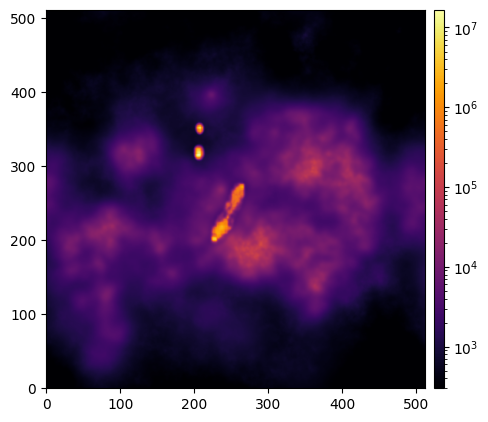

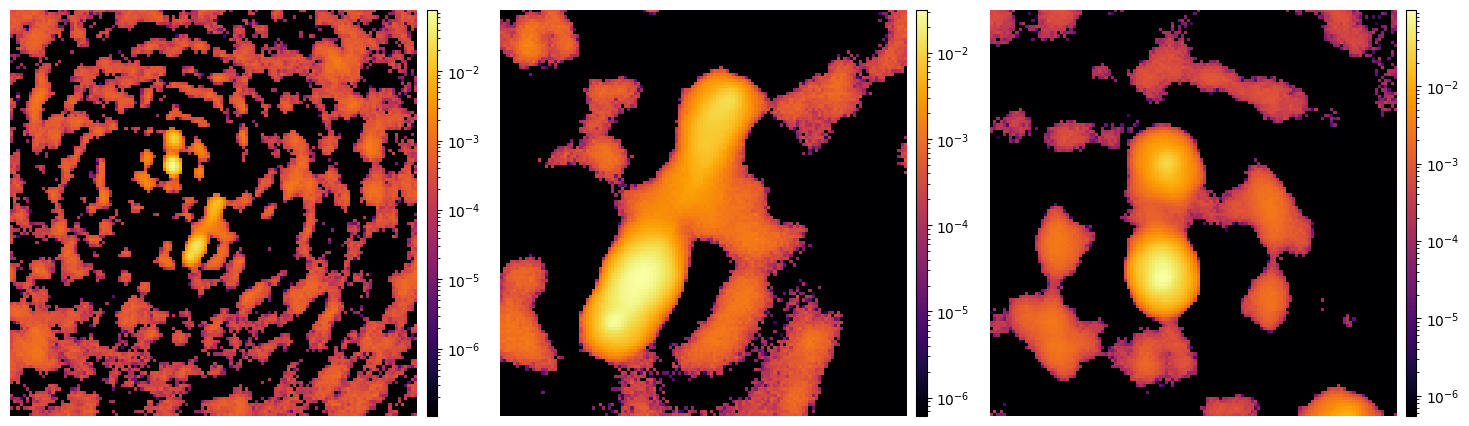

In [211]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')


sky_bg = optim_cfg.instantiate_sec('sky_bg.3')
sky_t0 = optim_cfg.instantiate_sec('sky_o0.3')
sky_t1 = optim_cfg.instantiate_sec('sky_o1.3')
sky_t2 = optim_cfg.instantiate_sec('sky_o2.3')


with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    samples, *_ = pickle.load(f)

rec_bg = samples.mean(sky_bg)
rec_t0 = map_signal(samples.mean(sky_t0), sky_t0.space, sky_bg.space)
rec_t1 = map_signal(samples.mean(sky_t1), sky_t1.space, sky_bg.space)
rec_t2 = map_signal(samples.mean(sky_t2), sky_t2.space, sky_bg.space)

rec = rec_bg + rec_t0 + rec_t1 + rec_t2
# rec = downsample(rec, 2)


def generate_data(rec, kernel, grid, n_std=1e-4):
    fft_kernel = build_fft_kernel(kernel, grid)
    truth = jax_fft_convolve(fft_kernel, grid)(rec)
    noise = n_std * jax.random.normal(key, truth.shape)
    data = truth + noise
    return data


hr_data = generate_data(rec, kernel, grid)
lr_data = generate_data(downsample(rec, grid.factor), downsample(kernel, grid.factor), grid.update(factor=1))

# mr_data = np.zeros((grid.factor**2+1, ) + lr_data.shape)
mr_data = np.zeros((3, ) + lr_data.shape)
mr_data[0] = lr_data
mr_data[1] = map_array(hr_data, grid, fr_response.f_grids[0])
mr_data[2] = map_array(hr_data, grid, fr_response.f_grids[1])
# mr_data[1:] = build_facet_array(hr_data, grid.factor)


plot_arrays(rec, norm='log', vmin=3e2, vmax=rec.max(), dpi=100)
plot_arrays(mr_data, rows=1, norm='log', ticks=0, cbar=True)


OPTIMIZE_KL: Starting 0001


s == p == set()


OPTIMIZE_KL: Iteration 0001 ⛰:+7.9361e+03
OPTIMIZE_KL: #(KL minimization steps) 28
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:    0.96±     0.0, avg:   +0.078±     0.0, #dof:  16384'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     2.4±     0.0, avg:     +1.6±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.014±     0.0, avg:    +0.12±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00024±     0.0, avg: -1.3e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.37±     0.0, avg:    +0.61±     0.0, #dof:      1'




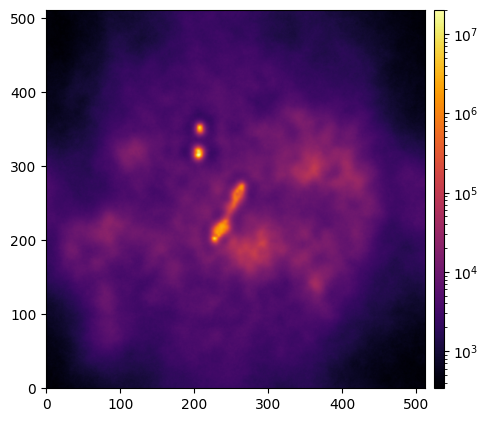

OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 ⛰:+5.0545e+04
OPTIMIZE_KL: #(KL minimization steps) 27
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     3.1±     0.0, avg:  -0.0012±     0.0, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     3.1±     0.0, avg:     +1.8±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.098±     0.0, avg:    +0.31±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00025±     0.0, avg: -1.3e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.35±     0.0, avg:    +0.59±     0.0, #dof:      1'




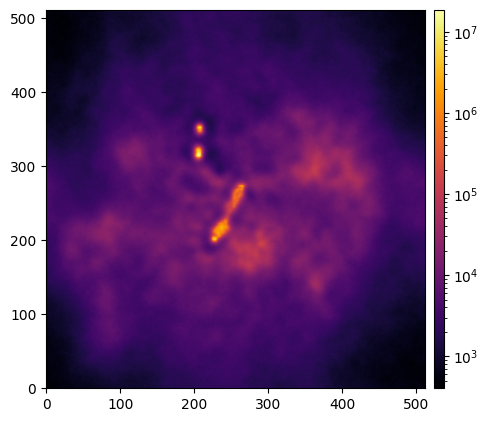

OPTIMIZE_KL: Starting 0003
OPTIMIZE_KL: Iteration 0003 ⛰:+4.2348e+04
OPTIMIZE_KL: #(KL minimization steps) 27
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     2.6±     0.0, avg:  -0.0067±     0.0, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     3.9±     0.0, avg:     +2.0±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:    0.31±     0.0, avg:    +0.56±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00026±     0.0, avg: -1.3e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.27±     0.0, avg:    +0.52±     0.0, #dof:      1'




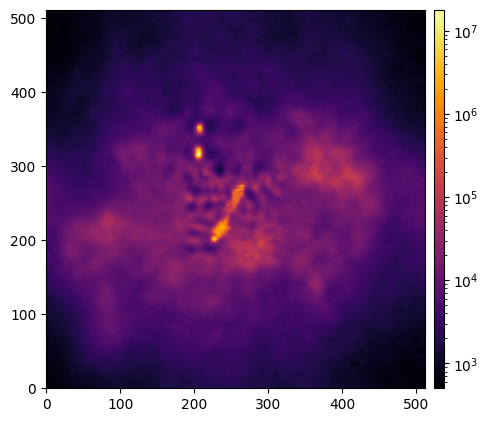

OPTIMIZE_KL: Starting 0004
OPTIMIZE_KL: Iteration 0004 ⛰:+3.8676e+04
OPTIMIZE_KL: #(KL minimization steps) 27
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     2.4±     0.0, avg:  -0.0043±     0.0, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     5.5±     0.0, avg:     +2.3±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:     0.6±     0.0, avg:    +0.78±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00027±     0.0, avg: -1.3e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.19±     0.0, avg:    +0.43±     0.0, #dof:      1'




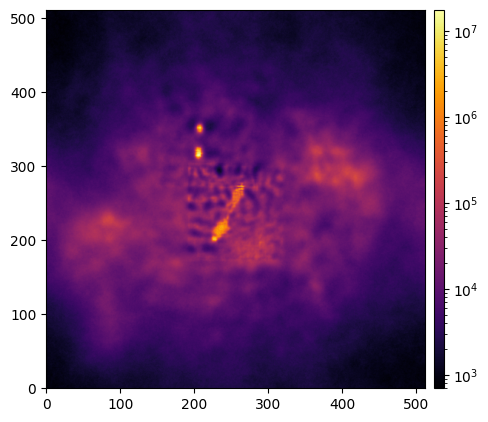

In [213]:
lh_dct1 = dict(
    data = mr_data[0],
    model = lr_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

lh_dct2 = dict(
    data = mr_data[1:],
    model = fr_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

lh_dicts = [lh_dct1, lh_dct2, lh_dct2, lh_dct2, lh_dct2]

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

samples, _ = optimize_kl(
    likelihood=lambda i: lh_dicts[i], 
    key=4,
    n_total_iterations=4,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=25,
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()


OPTIMIZE_KL: Iteration 0001 ⛰:+3.5842e+04
OPTIMIZE_KL: #(KL minimization steps) 26
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     2.2±     0.0, avg:    +0.15±     0.0, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     2.5±     0.0, avg:     +1.6±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.077±     0.0, avg:    +0.28±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00025±     0.0, avg: -1.2e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.25±     0.0, avg:     +0.5±     0.0, #dof:      1'




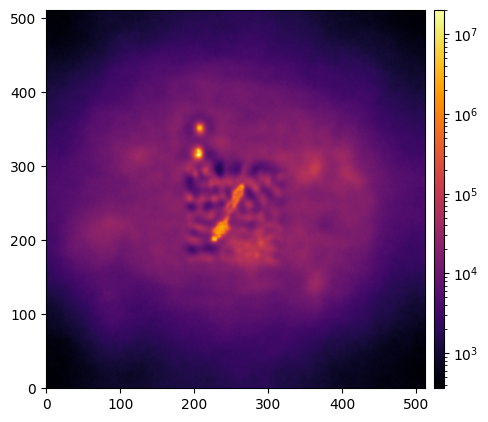

OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 ⛰:+3.2756e+04
OPTIMIZE_KL: #(KL minimization steps) 26
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     2.0±     0.0, avg:    +0.13±     0.0, #dof:  32768'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     3.9±     0.0, avg:     +2.0±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:    0.15±     0.0, avg:    +0.39±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00027±     0.0, avg: -1.4e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.28±     0.0, avg:    +0.53±     0.0, #dof:      1'




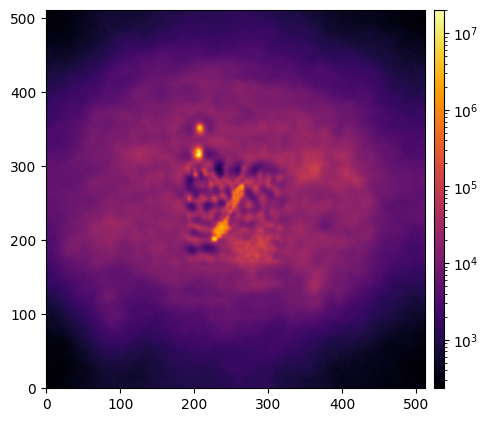

In [197]:
lh_dct = dict(
    data = mr_data,
    model = mr_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=4,
    n_total_iterations=2,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=25,
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()


OPTIMIZE_KL: Iteration 0001 ⛰:+3.6567e+04
OPTIMIZE_KL: #(KL minimization steps) 17
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±     0.0, avg:    +0.17±     0.0, #dof:  65536'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     1.3±     0.0, avg:     +1.1±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.023±     0.0, avg:    +0.15±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00021±     0.0, avg: -8.7e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.21±     0.0, avg:    +0.46±     0.0, #dof:      1'




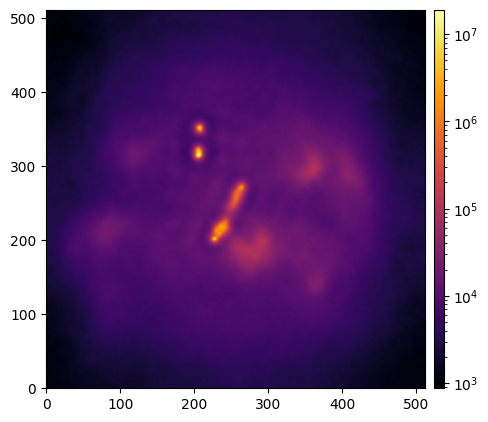

OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 ⛰:+3.4208e+04
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.0±     0.0, avg:   +0.096±     0.0, #dof:  65536'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     1.8±     0.0, avg:     +1.3±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.019±     0.0, avg:    +0.14±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00023±     0.0, avg:   -1e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.31±     0.0, avg:    +0.56±     0.0, #dof:      1'




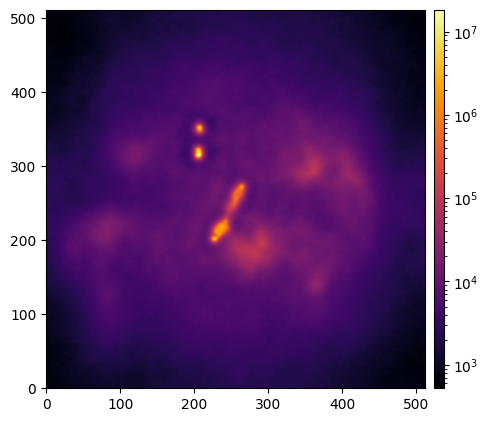

In [157]:
lh_dct = dict(
    data = lr_data,
    model = lr_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=4,
    n_total_iterations=2,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()


OPTIMIZE_KL: Iteration 0001 ⛰:+1.4653e+05
OPTIMIZE_KL: #(KL minimization steps) 17
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±     0.0, avg:    +0.16±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     1.3±     0.0, avg:     +1.2±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.027±     0.0, avg:    +0.16±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00022±     0.0, avg: -9.1e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.22±     0.0, avg:    +0.47±     0.0, #dof:      1'




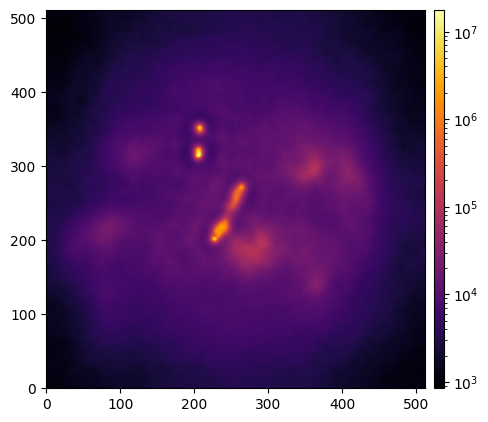

OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 ⛰:+1.3806e+05
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±     0.0, avg:   +0.099±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     1.8±     0.0, avg:     +1.3±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.027±     0.0, avg:    +0.16±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00023±     0.0, avg:   -1e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.31±     0.0, avg:    +0.55±     0.0, #dof:      1'




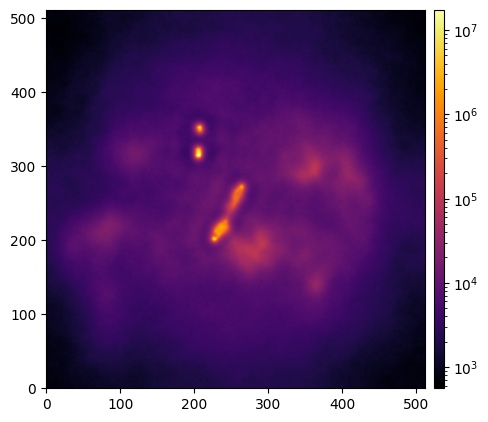

In [158]:
lh_dct = dict(
    data = hr_data,
    model = hr_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=4,
    n_total_iterations=2,
    n_samples=0,
    draw_linear_kwargs=dict(
        cg_kwargs=dict(
            maxiter=1000,
            name=None,
        ),
    ),
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)